# AI 651 - PA 1
# Task 2: Autoformer - Leaderboard Challenge


Name: Bimal Rehman

Roll No.: 25280081


In [2]:
import os
import zipfile
from pathlib import Path

if Path("/content/Question 2.zip").exists() and not Path("/content/Question 2").exists():
    zipfile.ZipFile("/content/Question 2.zip").extractall("/content")
if Path("/content/Question 2/Data").is_dir():
    os.chdir("/content/Question 2")
assert Path("Data").is_dir(), "Run from the folder that holds Data/"
print(os.getcwd())

/content/Question 2


In [3]:
import math
import time

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

DATA, RESULTS, FIGURES = Path("Data"), Path("results"), Path("figures")
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9})
H, L, LABEL = 168, 168, 84          # horizon, encoder length, decoder label = L/2 as in the paper
SEEDS = (0, 1, 2)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "device", DEVICE)

torch 2.11.0+cu130 device cuda


## 1. Data checks

In [4]:
train = pd.read_csv(DATA / "student_train.csv")
test = pd.read_csv(DATA / "student_test.csv")
external = pd.read_csv(DATA / "optional_external_data.csv")
y = train["value"].to_numpy(float)
n, total = len(y), len(external)

assert n == 43656 and total == 43824 and len(test) == H
assert (np.diff(train.time_idx) == 1).all() and (np.diff(external.time_idx) == 1).all()
assert test.time_idx.iloc[0] == 43657 and test.time_idx.iloc[-1] == 43824
assert train["value"].notna().all() and (y >= 0).all() and external.notna().all().all()
binary = ["feature_G", "feature_H", "feature_I", "feature_J"]
assert (external[binary].sum(axis=1) == 1).all()
print(f"history {n}, external {total}, test {len(test)}")
print(train["value"].describe().round(2).to_dict())
print("skew", round(train["value"].skew(), 2), "zeros", int((y == 0).sum()))

history 43656, external 43824, test 168
{'count': 43656.0, 'mean': 98.17, 'std': 90.83, 'min': 0.0, '25%': 30.0, '50%': 73.0, '75%': 136.0, 'max': 994.0}
skew 1.83 zeros 2


## 2. Exploration: periodic structure and covariates

ACF at lags 1, 6, 12, 24, 48, 168: [0.966 0.749 0.57  0.401 0.158 0.028]
top periodogram periods (samples): [  269.5 10914.    183.4   386.3    24.    338.4   379.6   289.1]
variance of log1p(value) explained by index mod 24: 0.0114, mod 168: 0.0142


,feature_A,feature_B,feature_C,feature_D,feature_E,feature_F,feature_G,feature_H,feature_I,feature_J,feature_A - feature_B
value,0.169,-0.088,-0.048,-0.245,0.019,-0.050,-0.033,-0.212,0.097,0.154,0.431
log1p value,0.308,0.019,-0.159,-0.348,0.032,-0.049,-0.064,-0.346,0.226,0.182,0.517


lead (steps) with the strongest |correlation|: {'feature_A': 0, 'feature_D': 0, 'feature_H': 5}


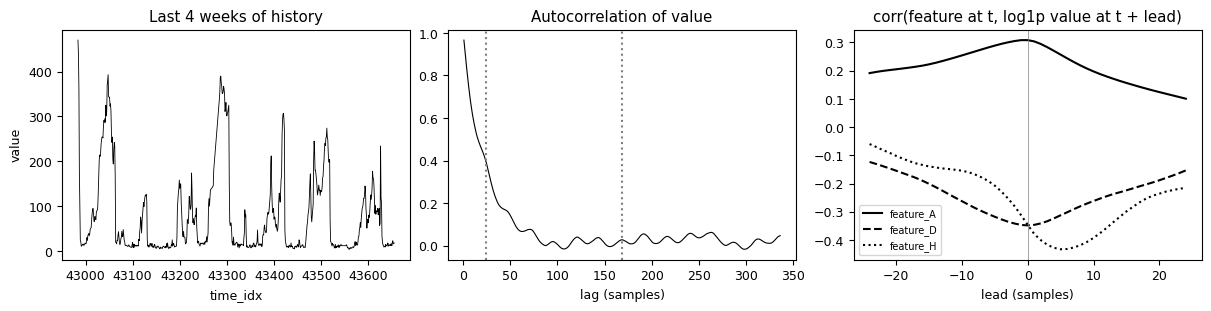

In [5]:
log_y = np.log1p(y)
centred = log_y - log_y.mean()

def acf(x, lags):
    x = x - x.mean()
    return np.array([np.dot(x[:-lag], x[lag:]) / np.dot(x, x) for lag in lags])

lags = np.arange(1, 337)
acf_values = acf(y, lags)
power = np.abs(np.fft.rfft(centred)) ** 2
frequency = np.fft.rfftfreq(n)
top = np.argsort(power[1:])[::-1][:8] + 1
print("ACF at lags 1, 6, 12, 24, 48, 168:", acf(y, [1, 6, 12, 24, 48, 168]).round(3))
print("top periodogram periods (samples):", np.round(1 / frequency[top], 1))
hour = np.arange(n) % 24
profile = pd.Series(log_y).groupby(hour).transform("mean").to_numpy()
week = pd.Series(log_y).groupby(np.arange(n) % 168).transform("mean").to_numpy()
r2 = lambda fit: 1 - np.sum((log_y - fit) ** 2) / np.sum(centred ** 2)
print(f"variance of log1p(value) explained by index mod 24: {r2(profile):.4f}, mod 168: {r2(week):.4f}")

features = external.iloc[:n, 1:]
correlation = pd.DataFrame({"value": features.corrwith(pd.Series(y)),
                            "log1p value": features.corrwith(pd.Series(log_y))})
correlation.loc["feature_A - feature_B"] = [np.corrcoef(features.feature_A - features.feature_B, v)[0, 1]
                                            for v in (y, log_y)]
display(correlation.round(3).T)
leads = np.arange(-24, 25)
z = (log_y - log_y.mean()) / log_y.std()
def lead_corr(column):
    x = features[column].to_numpy(float)
    x = (x - x.mean()) / x.std()
    return [np.mean(x[:n - k] * z[k:]) if k >= 0 else np.mean(x[-k:] * z[:n + k]) for k in leads]
lead_table = pd.DataFrame({c: lead_corr(c) for c in ["feature_A", "feature_D", "feature_H"]}, index=leads)
print("lead (steps) with the strongest |correlation|:",
      {c: int(lead_table[c].abs().idxmax()) for c in lead_table})

fig, axes = plt.subplots(1, 3, figsize=(12, 3), layout="constrained")
axes[0].plot(np.arange(n - 24 * 28, n), y[-24 * 28:], color="black", lw=0.6)
axes[0].set(title="Last 4 weeks of history", xlabel="time_idx", ylabel="value")
axes[1].plot(lags, acf_values, color="black", lw=0.8)
for lag in (24, 168):
    axes[1].axvline(lag, color="gray", ls=":")
axes[1].set(title="Autocorrelation of value", xlabel="lag (samples)")
for c, style in zip(lead_table, ["-", "--", ":"]):
    axes[2].plot(leads, lead_table[c], color="black", ls=style, label=c)
axes[2].axvline(0, color="gray", lw=0.5)
axes[2].set(title="corr(feature at t, log1p value at t + lead)", xlabel="lead (samples)")
axes[2].legend(fontsize=7)
fig.savefig(FIGURES / "T2-1.pdf")
plt.show()

## 3. Chronological validation protocol


In [6]:
N_FIT, N_STOP = int(0.7 * n), int(0.8 * n)
block_origins = np.arange(N_STOP, n - H + 1, H)
fit_origins = np.arange(L, N_FIT - H + 1, 2)          # one epoch = these windows, stride 2
stop_origins = np.arange(N_FIT, N_STOP - H + 1, 24)
print(f"fit windows/epoch {len(fit_origins)}, early-stop windows {len(stop_origins)}, "
      f"evaluation blocks {len(block_origins)} (time_idx {block_origins[0] + 1}-{block_origins[-1] + H})")

fit windows/epoch 15112, early-stop windows 175, evaluation blocks 51 (time_idx 34925-43492)


## 4. Inputs: covariate marks, target scaling, windows

In [7]:
def build_marks():
    e = external.copy()
    e["dew_spread"] = e.feature_A - e.feature_B        # feature_A minus feature_B
    for c in ("feature_D", "feature_E", "feature_F"):
        e[c] = np.log1p(e[c])                          # heavy-tailed accumulators
    continuous = ["feature_A", "feature_B", "feature_C", "feature_D", "feature_E", "feature_F", "dew_spread"]
    for c in ("dew_spread", "feature_D", "feature_H"):
        for w in (6, 24):
            e[f"{c}_mean{w}"] = e[c].rolling(w, min_periods=1).mean()   # trailing, covariates only
            continuous.append(f"{c}_mean{w}")
    stats = e.loc[:N_FIT - 1, continuous]
    e[continuous] = (e[continuous] - stats.mean()) / stats.std()
    step = np.arange(total)
    time_marks = np.stack([np.sin(2 * np.pi * step / 24), np.cos(2 * np.pi * step / 24)], 1)
    covariates = e[continuous + binary].to_numpy(np.float32)
    return np.concatenate([time_marks, covariates], 1).astype(np.float32), covariates.shape[1]

MARKS, N_COV = build_marks()
print("marks per step:", MARKS.shape[1], "(2 time + %d covariate)" % N_COV)

class Target:
    def __init__(self, kind):
        self.kind = kind
        z = self.forward(y[:N_FIT])
        self.mean, self.std = z.mean(), z.std()
    def forward(self, v):
        return np.sqrt(v) if self.kind == "sqrt" else v
    def scale(self, v):
        return (self.forward(v) - self.mean) / self.std
    def unscale(self, z):
        v = z * self.std + self.mean
        return np.clip(v, 0, None) ** 2 if self.kind == "sqrt" else np.clip(v, 0, None)

# Covariate columns inside MARKS (columns 0 and 1 are the two time marks, covariates start at 2).
COV_NAMES = ["feature_A", "feature_B", "feature_C", "feature_D", "feature_E", "feature_F", "dew_spread",
             "dew_spread_mean6", "dew_spread_mean24", "feature_D_mean6", "feature_D_mean24",
             "feature_H_mean6", "feature_H_mean24"] + binary
GROUPS = {   # covariate groups removed one at a time in section 8b
    "A, B, spread": ["feature_A", "feature_B", "dew_spread", "dew_spread_mean6", "dew_spread_mean24"],
    "C": ["feature_C"],
    "D and its means": ["feature_D", "feature_D_mean6", "feature_D_mean24"],
    "E": ["feature_E"],
    "F": ["feature_F"],
    "G to J and H means": binary + ["feature_H_mean6", "feature_H_mean24"],
}
assert len(COV_NAMES) == N_COV and all(c in COV_NAMES for g in GROUPS.values() for c in g)

def make_batch(origins, series, covariates):
    enc = origins[:, None] + np.arange(-L, 0)
    dec = origins[:, None] + np.arange(-LABEL, H)
    x = series[enc][..., None].astype(np.float32)
    enc_mark, dec_mark = MARKS[enc].copy(), MARKS[dec].copy()
    if covariates == "none":
        enc_mark[..., 2:] = 0
        dec_mark[..., 2:] = 0
    elif covariates == "none, no time marks":          # no external file and no index mod 24 marks
        enc_mark[...] = 0
        dec_mark[...] = 0
    elif covariates == "past":                          # horizon covariates unknown: hold last observed row
        dec_mark[:, LABEL:, 2:] = MARKS[origins - 1, None, 2:]
    elif covariates.startswith("drop:"):                # zero one covariate group (zero equals the fit mean)
        for column in GROUPS[covariates[5:]]:
            enc_mark[..., 2 + COV_NAMES.index(column)] = 0
            dec_mark[..., 2 + COV_NAMES.index(column)] = 0
    return [torch.from_numpy(a).to(DEVICE) for a in (x, enc_mark, dec_mark)]


marks per step: 19 (2 time + 17 covariate)


## 5. Autoformer

In [8]:
import math
import torch
from torch import nn
from torch.nn import functional as F


class SeriesDecomp(nn.Module):
    """Moving-average trend with replicated edges; returns (seasonal, trend)."""
    def __init__(self, kernel=25):
        super().__init__()
        self.kernel = kernel

    def forward(self, x):                        # [B,T,C]
        pad = self.kernel // 2
        padded = torch.cat([x[:, :1].expand(-1, pad, -1), x, x[:, -1:].expand(-1, pad, -1)], 1)
        trend = F.avg_pool1d(padded.transpose(1, 2), self.kernel, stride=1).transpose(1, 2)
        return x - trend, trend


def aggregate_delays(values, delays, weights):
    # values [B,h,e,T]; delays, weights [B,K]; position t reads t - delay (mod T)
    length = values.shape[-1]
    time = torch.arange(length, device=values.device)
    mixed = torch.zeros_like(values)
    for j in range(delays.shape[1]):
        index = ((time - delays[:, j:j + 1]) % length)[:, None, None, :].expand_as(values)
        mixed = mixed + weights[:, j, None, None, None] * values.gather(-1, index)
    return mixed


class AutoCorrelation(nn.Module):
    def __init__(self, d, heads, factor=1):
        super().__init__()
        self.heads, self.factor = heads, factor
        self.query, self.key, self.value, self.out = (nn.Linear(d, d) for _ in range(4))

    def forward(self, x, memory):                # [B,T,d], [B,S,d]
        batch, length, width = x.shape
        if memory.shape[1] < length:             # zero-pad keys/values to the query length
            memory = F.pad(memory, (0, 0, 0, length - memory.shape[1]))
        memory = memory[:, :length]
        shape = (batch, length, self.heads, width // self.heads)
        q = self.query(x).view(shape).permute(0, 2, 3, 1)       # [B,h,e,T]
        k = self.key(memory).view(shape).permute(0, 2, 3, 1)
        v = self.value(memory).view(shape).permute(0, 2, 3, 1)
        spectrum = torch.fft.rfft(q, dim=-1) * torch.fft.rfft(k, dim=-1).conj()
        scores = torch.fft.irfft(spectrum, n=length, dim=-1).mean((1, 2))   # [B,T]
        top = max(1, int(self.factor * math.log(length)))
        selected, delays = scores.topk(top, dim=-1)
        self.last_delays = delays.detach()      # kept for the lag histogram
        mixed = aggregate_delays(v, delays, selected.softmax(-1))
        return self.out(mixed.permute(0, 3, 1, 2).reshape(batch, length, width))


class SeasonalNorm(nn.Module):
    """LayerNorm, then remove the time mean (Autoformer's seasonal-part norm)."""
    def __init__(self, d):
        super().__init__()
        self.norm = nn.LayerNorm(d)

    def forward(self, x):
        x = self.norm(x)
        return x - x.mean(1, keepdim=True)


def feed_forward(d, d_ff, dropout):
    return nn.Sequential(nn.Linear(d, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, d))


class EncoderLayer(nn.Module):
    def __init__(self, d, heads, d_ff, kernel, dropout, factor=1):
        super().__init__()
        self.mix, self.ff = AutoCorrelation(d, heads, factor), feed_forward(d, d_ff, dropout)
        self.decomp1, self.decomp2 = SeriesDecomp(kernel), SeriesDecomp(kernel)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x, _ = self.decomp1(x + self.drop(self.mix(x, x)))
        x, _ = self.decomp2(x + self.drop(self.ff(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d, heads, d_ff, kernel, dropout, factor=1):
        super().__init__()
        self.self_mix, self.cross_mix = AutoCorrelation(d, heads, factor), AutoCorrelation(d, heads, factor)
        self.ff = feed_forward(d, d_ff, dropout)
        self.decomps = nn.ModuleList(SeriesDecomp(kernel) for _ in range(3))
        self.trend_proj = nn.Conv1d(d, 1, 3, padding=1, padding_mode="circular", bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, memory):
        x, trend1 = self.decomps[0](x + self.drop(self.self_mix(x, x)))
        x, trend2 = self.decomps[1](x + self.drop(self.cross_mix(x, memory)))
        x, trend3 = self.decomps[2](x + self.drop(self.ff(x)))
        trend = self.trend_proj((trend1 + trend2 + trend3).transpose(1, 2)).transpose(1, 2)
        return x, trend


class Embedding(nn.Module):
    """Value token (circular conv) plus a linear map of the step's covariates/time marks."""
    def __init__(self, marks, d, dropout):
        super().__init__()
        self.token = nn.Conv1d(1, d, 3, padding=1, padding_mode="circular", bias=False)
        self.mark = nn.Linear(marks, d, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mark):
        return self.drop(self.token(x.transpose(1, 2)).transpose(1, 2) + self.mark(mark))


class Autoformer(nn.Module):
    def __init__(self, marks, horizon=168, label=84, d=16, heads=4, d_ff=32,
                 enc_layers=2, dec_layers=1, kernel=25, dropout=0.05, trend_head=True,
                 context=168, factor=1):
        super().__init__()
        self.horizon, self.label = horizon, label
        self.trend_head = nn.Linear(context, horizon) if trend_head else None
        self.decomp = SeriesDecomp(kernel)
        self.enc_embed, self.dec_embed = Embedding(marks, d, dropout), Embedding(marks, d, dropout)
        self.encoder = nn.ModuleList(EncoderLayer(d, heads, d_ff, kernel, dropout, factor)
                                     for _ in range(enc_layers))
        self.decoder = nn.ModuleList(DecoderLayer(d, heads, d_ff, kernel, dropout, factor)
                                     for _ in range(dec_layers))
        self.enc_norm, self.dec_norm = SeasonalNorm(d), SeasonalNorm(d)
        self.projection = nn.Linear(d, 1)

    def forward(self, x, enc_mark, dec_mark):    # x [B,L,1]; marks [B,L,M], [B,label+H,M]
        seasonal, input_trend = self.decomp(x)
        mean = x.mean(1, keepdim=True).expand(-1, self.horizon, -1)
        trend = torch.cat([input_trend[:, -self.label:], mean], 1)
        seasonal = F.pad(seasonal[:, -self.label:], (0, 0, 0, self.horizon))
        memory = self.enc_embed(x, enc_mark)
        for layer in self.encoder:
            memory = layer(memory)
        memory = self.enc_norm(memory)
        out = self.dec_embed(seasonal, dec_mark)
        for layer in self.decoder:
            out, layer_trend = layer(out, memory)
            trend = trend + layer_trend
        forecast = (trend + self.projection(self.dec_norm(out)))[:, -self.horizon:, 0]
        if self.trend_head is not None:               # linear head on the input trend, as in Task 1 Part 2
            forecast = forecast + self.trend_head(input_trend[..., 0])
        return forecast


class CovHead(nn.Module):
    """Pointwise MLP for every forecast step. Inputs are the covariates and time marks at that step, the covariates
    at the forecast origin, the horizon fraction and three summaries of the observed history (last value, mean of the
    last 24 and of the last 168 values)."""
    def __init__(self, marks, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(marks + 7 + 4, hidden), nn.GELU(), nn.Linear(hidden, hidden),
                                 nn.GELU(), nn.Linear(hidden, 1))

    def forward(self, x, enc_mark, dec_mark, horizon, label):
        batch = x.shape[0]
        step = dec_mark[:, label:, :]
        origin = enc_mark[:, -1:, 2:9].expand(-1, horizon, -1)
        fraction = torch.linspace(0, 1, horizon, device=x.device).view(1, horizon, 1).expand(batch, -1, -1)
        s = x[..., 0]
        summary = torch.stack([s[:, -1], s[:, -24:].mean(1), s[:, -168:].mean(1)], 1)[:, None, :].expand(-1, horizon, -1)
        return self.net(torch.cat([step, origin, fraction, summary], -1)).squeeze(-1)


class Autoformer2(Autoformer):
    """The Autoformer above plus a covariate head and an optional per step weight on the last observed value.
    Series decomposition and Auto-Correlation are unchanged and still produce the main forecast."""
    def __init__(self, marks, cov_head=True, hidden=64, anchor=False, **kw):
        super().__init__(marks, **kw)
        self.cov_head = CovHead(marks, hidden) if cov_head else None
        self.gate = nn.Parameter(torch.exp(-torch.arange(self.horizon).float() / 6.0)) if anchor else None

    def forward(self, x, enc_mark, dec_mark):
        out = super().forward(x, enc_mark, dec_mark)
        if self.cov_head is not None:
            out = out + self.cov_head(x, enc_mark, dec_mark, self.horizon, self.label)
        if self.gate is not None:
            out = out + self.gate * x[:, -1, 0][:, None]
        return out


def new_model(marks, trend_head=True, factor=1, cov_head=False, anchor=False):
    if cov_head or anchor:
        return Autoformer2(marks, cov_head=cov_head, anchor=anchor, trend_head=trend_head, factor=factor)
    return Autoformer(marks, trend_head=trend_head, factor=factor)


In [9]:
# Dir
check = aggregate_delays(torch.tensor([10., 20., 30., 40.]).reshape(1, 1, 1, 4),
                         torch.tensor([[1, 3]]), torch.tensor([[.75, .25]]))
assert torch.allclose(check.flatten(), torch.tensor([35., 15., 25., 25.]))
print("parameters with %d marks:" % MARKS.shape[1],
      sum(p.numel() for p in Autoformer(MARKS.shape[1]).parameters()), "with trend head,",
      sum(p.numel() for p in Autoformer(MARKS.shape[1], trend_head=False).parameters()), "without")

parameters with 19 marks: 36793 with trend head, 8401 without


## 6. Training, forecasting and metrics

In [10]:
def predict(model, origins, series, covariates, batch=256):
    model.eval()
    with torch.no_grad():
        return np.concatenate([model(*make_batch(origins[i:i + batch], series, covariates)).cpu().numpy()
                               for i in range(0, len(origins), batch)])

refit_origins = np.arange(L, N_STOP - H + 1, 2)         # fit windows extended to the end of the early-stop span
full_origins = np.arange(L, n - H + 1, 2)               # all history, used for the final refit

def train_model(seed, covariates, target, head, lr, max_epochs=10, patience=3, factor=1, refit=False,
                fixed_epochs=None, cov_head=False, anchor=False):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    scaler = Target(target)
    series = scaler.scale(y)
    model = new_model(MARKS.shape[1], head, factor, cov_head, anchor).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    origins_used = full_origins if refit == "all" else refit_origins if refit else fit_origins
    stop_target = series[stop_origins[:, None] + np.arange(H)]
    best, best_state, epochs, wait, started = np.inf, None, 0, 0, time.time()
    limit = fixed_epochs or max_epochs
    while epochs < limit and (fixed_epochs or wait < patience):
        model.train()
        for index in np.array_split(rng.permutation(origins_used), len(origins_used) // 64):
            x, enc_mark, dec_mark = make_batch(index, series, covariates)
            target_z = torch.from_numpy(series[index[:, None] + np.arange(H)].astype(np.float32)).to(DEVICE)
            loss = F.mse_loss(model(x, enc_mark, dec_mark), target_z)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        epochs += 1
        if fixed_epochs:                                  # refit arm: no early stopping, keep the last epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            continue
        stop_loss = np.mean((predict(model, stop_origins, series, covariates) - stop_target) ** 2)
        if stop_loss < best:
            best, wait = stop_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
    model.load_state_dict(best_state)
    return model, scaler, dict(seed=seed, epochs=epochs, best_epoch=epochs - wait, stop_loss=best, seconds=time.time() - started)

def block_forecast(model, scaler, covariates):
    return scaler.unscale(predict(model, block_origins, scaler.scale(y), covariates))

ACTUAL = y[block_origins[:, None] + np.arange(H)]

def metrics(forecast, actual=ACTUAL):
    error = forecast - actual
    denominator = np.abs(actual) + np.abs(forecast)
    smape = np.where(denominator > 0, 2 * np.abs(error) / np.where(denominator > 0, denominator, 1), 0)
    return dict(MAE=np.abs(error).mean(), RMSE=np.sqrt((error ** 2).mean()), sMAPE=100 * smape.mean())

## 7. Baselines on the same 51 blocks

In [11]:
last = y[block_origins - 1][:, None]
baselines = {
    "Fit-period mean": np.full_like(ACTUAL, y[:N_FIT].mean()),
    "Last value": np.repeat(last, H, 1),
    "Seasonal naive (24)": np.tile(y[block_origins[:, None] + np.arange(-24, 0)], (1, H // 24)),
}

def ridge(X, target, lam=1e-2):
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ target)

X_cov = np.column_stack([MARKS[:, 2:], np.ones(total)])  # covariates at the forecast step only
baselines["Ridge on future covariates"] = np.clip(X_cov[block_origins[:, None] + np.arange(H)]
                                                  @ ridge(X_cov[:N_FIT], y[:N_FIT]), 0, None)

# One ridge per horizon step on the last L values plus that step's covariates
scale = Target("raw")
history = lambda origins: scale.scale(y[origins[:, None] + np.arange(-L, 0)])
linear_fit = fit_origins[::2]
hybrid = np.empty_like(ACTUAL)
for h in range(H):
    X_fit = np.column_stack([history(linear_fit), MARKS[linear_fit + h], np.ones(len(linear_fit))])
    X_block = np.column_stack([history(block_origins), MARKS[block_origins + h], np.ones(len(block_origins))])
    hybrid[:, h] = X_block @ ridge(X_fit, y[linear_fit + h])
baselines["Ridge on history + future covariates"] = np.clip(hybrid, 0, None)

baseline_table = pd.DataFrame({k: metrics(v) for k, v in baselines.items()}).T
baseline_table.to_csv(RESULTS / "baselines.csv")
display(baseline_table.round(2))

,MAE,RMSE,sMAPE
Fit-period mean,69.20,93.29,75.54
Last value,95.79,143.58,86.84
Seasonal naive (24),93.10,137.29,90.16
Ridge on future covariates,53.13,76.46,67.55
Ridge on history + future covariates,50.27,71.55,67.13


In [23]:
# 7b. linear proxy ridge
def ridge_rmse(columns):
    X = np.column_stack([MARKS[:, [2 + COV_NAMES.index(c) for c in columns]], np.ones(total)])
    fit = ridge(X[:N_FIT], y[:N_FIT])
    return metrics(np.clip(X[block_origins[:, None] + np.arange(H)] @ fit, 0, None))["RMSE"]

proxy = pd.DataFrame({
    "RMSE with all covariates": ridge_rmse(COV_NAMES),
    "RMSE with no covariates (fit mean)": metrics(baselines["Fit-period mean"])["RMSE"],
}, index=["all"]).T
rows = [{"group": name, "RMSE dropped": ridge_rmse([c for c in COV_NAMES if c not in cols]),
         "RMSE alone": ridge_rmse(cols)} for name, cols in GROUPS.items()]
display(proxy.round(2))
display(pd.DataFrame(rows).round(2))
proxy_table = pd.DataFrame(rows)
proxy_table.to_csv(RESULTS / "covariate_proxy.csv", index=False)


,all
RMSE with all covariates,76.46
RMSE with no covariates (fit mean),93.29


,group,RMSE dropped,RMSE alone
0,"A, B, spread",84.24,83.87
1,C,76.61,94.54
2,D and its means,77.67,87.13
3,E,76.58,93.29
4,F,76.82,93.18
5,G to J and H means,80.00,87.53


## 8. Ablations across three seeds

External data three ways (none, past only, past plus future). With past plus future covariates, three single changes: no linear trend head, a square root target, and the paper's learning rate of 1e-4.
These six arms are the candidate set for the submitted model.

In [13]:
DEFAULT = dict(covariates="future", target="raw", head=True, lr=1e-3)
CONFIGS = {
    "none": dict(covariates="none"),
    "past": dict(covariates="past"),
    "past + future": {},
    "past + future, no head": dict(head=False),
    "past + future, sqrt target": dict(target="sqrt"),
    "past + future, lr 1e-4": dict(lr=1e-4),
}
runs, forecasts, models = [], {}, {}
for number, (name, change) in enumerate(CONFIGS.items()):
    settings = {**DEFAULT, **change}
    for seed in SEEDS:
        path = RESULTS / f"model_{number}_seed{seed}.pt"
        if path.exists():                               # resume a finished run
            saved = torch.load(path, map_location=DEVICE, weights_only=False)
            model = new_model(MARKS.shape[1], settings["head"], settings.get("factor", 1), settings.get("cov_head", False), settings.get("anchor", False)).to(DEVICE)
            model.load_state_dict(saved["state"])
            scaler, record = Target(settings["target"]), saved["record"]
        else:
            model, scaler, record = train_model(seed, **settings)
            torch.save({"state": model.state_dict(), "record": record}, path)
        forecast = block_forecast(model, scaler, settings["covariates"])
        record = dict(record, config=name, parameters=sum(p.numel() for p in model.parameters()), **metrics(forecast))
        runs.append(record)
        forecasts[name, seed], models[name, seed] = forecast, (model, scaler, settings)
        print({k: (round(float(v), 3) if isinstance(v, (float, np.floating)) else v) for k, v in record.items()}, flush=True)
runs = pd.DataFrame(runs)
runs.to_csv(RESULTS / "ablation_runs.csv", index=False)
summary = runs.groupby("config", sort=False)[["MAE", "RMSE", "sMAPE", "epochs", "parameters"]].agg(["mean", "std"])
summary.to_csv(RESULTS / "ablation_summary.csv")
display(summary.round(2))

{'seed': 0, 'epochs': 9, 'stop_loss': 0.709, 'seconds': 62.718, 'config': 'none', 'parameters': 36793, 'MAE': 63.508, 'RMSE': 86.338, 'sMAPE': 71.287}
{'seed': 1, 'epochs': 4, 'stop_loss': 0.715, 'seconds': 26.308, 'config': 'none', 'parameters': 36793, 'MAE': 64.124, 'RMSE': 86.766, 'sMAPE': 71.461}
{'seed': 2, 'epochs': 6, 'stop_loss': 0.715, 'seconds': 40.0, 'config': 'none', 'parameters': 36793, 'MAE': 63.855, 'RMSE': 87.405, 'sMAPE': 71.71}
{'seed': 0, 'epochs': 5, 'stop_loss': 0.69, 'seconds': 32.603, 'config': 'past', 'parameters': 36793, 'MAE': 62.836, 'RMSE': 86.024, 'sMAPE': 70.334}
{'seed': 1, 'epochs': 4, 'stop_loss': 0.707, 'seconds': 26.101, 'config': 'past', 'parameters': 36793, 'MAE': 63.952, 'RMSE': 86.14, 'sMAPE': 71.377}
{'seed': 2, 'epochs': 4, 'stop_loss': 0.699, 'seconds': 25.729, 'config': 'past', 'parameters': 36793, 'MAE': 64.724, 'RMSE': 86.803, 'sMAPE': 72.224}
{'seed': 0, 'epochs': 7, 'stop_loss': 0.419, 'seconds': 44.846, 'config': 'past + future', 'paramet

MAE         RMSE        sMAPE       epochs  \
                             mean   std   mean   std   mean   std   mean   
config                                                                     
none                        63.83  0.31  86.84  0.54  71.49  0.21   6.33   
past                        63.84  0.95  86.32  0.42  71.31  0.95   4.33   
past + future               47.85  0.27  67.85  0.77  66.74  1.07   8.00   
past + future, no head      52.83  2.26  73.87  2.83  69.86  0.59   7.33   
past + future, sqrt target  44.10  0.65  66.65  0.43  54.48  0.87   8.67   
past + future, lr 1e-4      48.97  0.71  70.13  0.43  66.29  1.05  10.00   

                                 parameters       
                             std       mean  std  
config                                            
none                        2.52    36793.0  0.0  
past                        0.58    36793.0  0.0  
past + future               1.00    36793.0  0.0  
past + future, no head      2.52     8401.0  0.0  
past + future, sqrt target  0.58    36793.0  0.0  
past + future, lr 1e-4      0.00    36793.0  0.0

In [14]:
# 8b. Diagnostic arms.
BASE = {**DEFAULT, "target": "sqrt"}
DIAGNOSTICS = {
    "no external, no time marks": dict(covariates="none, no time marks", target="raw"),
    "past + future, lr 1e-4, up to 25 epochs": dict(lr=1e-4, max_epochs=25, target="raw"),
    "past + future, c=2": dict(factor=2, target="raw"),
    "past + future, c=3": dict(factor=3, target="raw"),
    "past + future, sqrt target, refit to 80%": dict(**{"target": "sqrt"}, refit=True, fixed_epochs=8),
    **{f"drop {name}": dict(covariates=f"drop:{name}", target="raw") for name in GROUPS},
}
for number, (name, change) in enumerate(DIAGNOSTICS.items(), start=len(CONFIGS)):
    settings = {**DEFAULT, **change}
    for seed in SEEDS:
        path = RESULTS / f"model_{number}_seed{seed}.pt"
        if path.exists():
            saved = torch.load(path, map_location=DEVICE, weights_only=False)
            model = new_model(MARKS.shape[1], settings["head"], settings.get("factor", 1), settings.get("cov_head", False), settings.get("anchor", False)).to(DEVICE)
            model.load_state_dict(saved["state"])
            scaler, record = Target(settings["target"]), saved["record"]
        else:
            model, scaler, record = train_model(seed, **settings)
            torch.save({"state": model.state_dict(), "record": record}, path)
        forecast = block_forecast(model, scaler, settings["covariates"])
        record = dict(record, config=name, parameters=sum(p.numel() for p in model.parameters()), **metrics(forecast))
        runs = pd.concat([runs, pd.DataFrame([record])], ignore_index=True)
        forecasts[name, seed] = forecast
        print({k: (round(float(v), 3) if isinstance(v, (float, np.floating)) else v) for k, v in record.items()}, flush=True)
runs.to_csv(RESULTS / "ablation_runs.csv", index=False)
summary = runs.groupby("config", sort=False)[["MAE", "RMSE", "sMAPE", "epochs", "parameters"]].agg(["mean", "std"])
summary.to_csv(RESULTS / "ablation_summary.csv")
display(summary.round(2))


{'seed': 0, 'epochs': 7, 'best_epoch': 4, 'stop_loss': 0.73, 'seconds': 55.156, 'config': 'no external, no time marks', 'parameters': 36793, 'MAE': 64.142, 'RMSE': 87.71, 'sMAPE': 71.543}
{'seed': 1, 'epochs': 10, 'best_epoch': 8, 'stop_loss': 0.727, 'seconds': 79.735, 'config': 'no external, no time marks', 'parameters': 36793, 'MAE': 63.679, 'RMSE': 85.962, 'sMAPE': 71.105}
{'seed': 2, 'epochs': 4, 'best_epoch': 1, 'stop_loss': 0.731, 'seconds': 30.899, 'config': 'no external, no time marks', 'parameters': 36793, 'MAE': 65.338, 'RMSE': 87.907, 'sMAPE': 72.592}
{'seed': 0, 'epochs': 25, 'best_epoch': 24, 'stop_loss': 0.411, 'seconds': 180.28, 'config': 'past + future, lr 1e-4, up to 25 epochs', 'parameters': 36793, 'MAE': 47.05, 'RMSE': 65.988, 'sMAPE': 66.71}
{'seed': 1, 'epochs': 23, 'best_epoch': 20, 'stop_loss': 0.403, 'seconds': 147.019, 'config': 'past + future, lr 1e-4, up to 25 epochs', 'parameters': 36793, 'MAE': 47.829, 'RMSE': 68.059, 'sMAPE': 67.107}
{'seed': 2, 'epochs': 

MAE         RMSE        sMAPE  \
                                           mean   std   mean   std   mean   
config                                                                      
none                                      63.83  0.31  86.84  0.54  71.49   
past                                      63.84  0.95  86.32  0.42  71.31   
past + future                             47.85  0.27  67.85  0.77  66.74   
past + future, no head                    52.83  2.26  73.87  2.83  69.86   
past + future, sqrt target                44.10  0.65  66.65  0.43  54.48   
past + future, lr 1e-4                    48.97  0.71  70.13  0.43  66.29   
no external, no time marks                64.39  0.86  87.19  1.07  71.75   
past + future, lr 1e-4, up to 25 epochs   47.97  1.00  67.79  1.69  66.95   
past + future, c=2                        47.05  2.01  66.61  1.19  67.01   
past + future, c=3                        46.83  1.18  67.29  0.99  67.59   
past + future, sqrt target, refit to 80%  42.05  1.79  63.41  2.29  52.99   
drop A, B, spread                         54.06  1.48  75.14  1.44  67.53   
drop C                                    47.29  1.75  66.86  1.78  67.65   
drop D and its means                      46.84  0.69  66.62  0.86  67.17   
drop E                                    47.93  1.22  69.07  1.72  69.66   
drop F                                    48.15  0.39  68.07  1.96  68.36   
drop G to J and H means                   48.26  0.59  69.41  0.94  69.92   

                                               epochs       parameters       
                                           std   mean   std       mean  std  
config                                                                       
none                                      0.21   6.33  2.52    36793.0  0.0  
past                                      0.95   4.33  0.58    36793.0  0.0  
past + future                             1.07   8.00  1.00    36793.0  0.0  
past + future, no head                    0.59   7.33  2.52     8401.0  0.0  
past + future, sqrt target                0.87   8.67  0.58    36793.0  0.0  
past + future, lr 1e-4                    1.05  10.00  0.00    36793.0  0.0  
no external, no time marks                0.76   7.00  3.00    36793.0  0.0  
past + future, lr 1e-4, up to 25 epochs   0.21  24.33  1.15    36793.0  0.0  
past + future, c=2                        1.79   8.00  2.00    36793.0  0.0  
past + future, c=3                        1.35   7.67  1.15    36793.0  0.0  
past + future, sqrt target, refit to 80%  1.75   8.00  0.00    36793.0  0.0  
drop A, B, spread                         1.28   6.33  1.15    36793.0  0.0  
drop C                                    0.61   7.67  2.08    36793.0  0.0  
drop D and its means                      2.76   8.00  2.65    36793.0  0.0  
drop E                                    0.89   9.67  0.58    36793.0  0.0  
drop F                                    1.69   9.33  1.15    36793.0  0.0  
drop G to J and H means                   2.17   9.00  1.00    36793.0  0.0

In [15]:
# 8c. Improved model
from sklearn.ensemble import HistGradientBoostingRegressor
ly, cov = np.log1p(y), MARKS[:, 2:]

def gbm_features(origins, steps):
    o, h = origins[:, None], steps[None, :]
    t = o + h
    ones = np.ones_like(t, float)
    last = ly[o - 1] * ones
    m24 = np.array([ly[k - 24:k].mean() for k in origins])[:, None] * ones
    m168 = np.array([ly[k - 168:k].mean() for k in origins])[:, None] * ones
    X = np.concatenate([cov[t], cov[o - 1].repeat(len(steps), 1)[:, :, :7], (h * ones)[..., None], last[..., None],
                        m24[..., None], m168[..., None], np.sin(2 * np.pi * t / 24)[..., None],
                        np.cos(2 * np.pi * t / 24)[..., None]], axis=2)
    return X.reshape(-1, X.shape[2]), t.reshape(-1)

Xg, tg = gbm_features(np.arange(L, N_FIT - H + 1, 12), np.arange(0, H, 4))
gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06, max_leaf_nodes=31, min_samples_leaf=60,
                                    l2_regularization=1.0, random_state=0).fit(Xg, np.sqrt(y[tg]))
Xb, _ = gbm_features(block_origins, np.arange(H))
gbm_forecast = np.clip(gbm.predict(Xb), 0, None).reshape(len(block_origins), H) ** 2
future_only = list(range(cov.shape[1])) + [Xg.shape[1] - 2, Xg.shape[1] - 1]     # covariates at the step plus time marks
gbm_future = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06, max_leaf_nodes=31, min_samples_leaf=60,
                                           l2_regularization=1.0, random_state=0).fit(Xg[:, future_only], np.sqrt(y[tg]))
baselines["Gradient boosting on future covariates only (comparison only)"] = np.clip(
    gbm_future.predict(Xb[:, future_only]), 0, None).reshape(len(block_origins), H) ** 2
baselines["Gradient boosting on covariates and history (comparison only)"] = gbm_forecast
baseline_table = pd.DataFrame({k: metrics(v) for k, v in baselines.items()}).T
baseline_table.to_csv(RESULTS / "baselines.csv")
display(baseline_table.round(2))
for seed in SEEDS:
    forecasts["gradient boosting (comparison only)", seed] = gbm_forecast

IMPROVED = {
    "covariate head": dict(cov_head=True, target="sqrt", max_epochs=30, patience=4),
    "covariate head + anchor": dict(cov_head=True, anchor=True, target="sqrt", max_epochs=30, patience=4),
}
for number, (name, change) in enumerate(IMPROVED.items(), start=100):
    settings = {**DEFAULT, **change}
    for seed in SEEDS:
        path = RESULTS / f"model_{number}_seed{seed}.pt"
        if path.exists():
            saved = torch.load(path, map_location=DEVICE, weights_only=False)
            model = new_model(MARKS.shape[1], settings["head"], 1, settings["cov_head"], settings.get("anchor", False)).to(DEVICE)
            model.load_state_dict(saved["state"])
            scaler, record = Target(settings["target"]), saved["record"]
        else:
            model, scaler, record = train_model(seed, **settings)
            torch.save({"state": model.state_dict(), "record": record}, path)
        forecast = block_forecast(model, scaler, settings["covariates"])
        record = dict(record, config=name, parameters=sum(p.numel() for p in model.parameters()), **metrics(forecast))
        runs = pd.concat([runs, pd.DataFrame([record])], ignore_index=True)
        forecasts[name, seed] = forecast
        print({k: (round(float(v), 3) if isinstance(v, (float, np.floating)) else v) for k, v in record.items()}, flush=True)
runs.to_csv(RESULTS / "ablation_runs.csv", index=False)
summary = runs.groupby("config", sort=False)[["MAE", "RMSE", "sMAPE", "epochs", "parameters"]].agg(["mean", "std"])
summary.to_csv(RESULTS / "ablation_summary.csv")
display(summary.round(2))


,MAE,RMSE,sMAPE
Fit-period mean,69.20,93.29,75.54
Last value,95.79,143.58,86.84
Seasonal naive (24),93.10,137.29,90.16
Ridge on future covariates,53.13,76.46,67.55
Ridge on history + future covariates,50.27,71.55,67.13
Gradient boosting on future covariates only (comparison only),44.38,68.72,50.18
Gradient boosting on covariates and history (comparison only),40.13,62.34,46.52


{'seed': 0, 'epochs': 9, 'best_epoch': 5, 'stop_loss': 0.28, 'seconds': 66.372, 'config': 'covariate head', 'parameters': 43002, 'MAE': 38.83, 'RMSE': 59.771, 'sMAPE': 46.018}
{'seed': 1, 'epochs': 9, 'best_epoch': 5, 'stop_loss': 0.279, 'seconds': 76.401, 'config': 'covariate head', 'parameters': 43002, 'MAE': 38.147, 'RMSE': 60.335, 'sMAPE': 45.293}
{'seed': 2, 'epochs': 10, 'best_epoch': 6, 'stop_loss': 0.267, 'seconds': 71.345, 'config': 'covariate head', 'parameters': 43002, 'MAE': 37.082, 'RMSE': 57.93, 'sMAPE': 43.819}
{'seed': 0, 'epochs': 9, 'best_epoch': 5, 'stop_loss': 0.282, 'seconds': 61.564, 'config': 'covariate head + anchor', 'parameters': 43170, 'MAE': 39.044, 'RMSE': 60.201, 'sMAPE': 45.859}
{'seed': 1, 'epochs': 9, 'best_epoch': 5, 'stop_loss': 0.28, 'seconds': 62.497, 'config': 'covariate head + anchor', 'parameters': 43170, 'MAE': 37.786, 'RMSE': 59.64, 'sMAPE': 45.4}
{'seed': 2, 'epochs': 10, 'best_epoch': 6, 'stop_loss': 0.27, 'seconds': 70.642, 'config': 'covari

MAE         RMSE        sMAPE  \
                                           mean   std   mean   std   mean   
config                                                                      
none                                      63.83  0.31  86.84  0.54  71.49   
past                                      63.84  0.95  86.32  0.42  71.31   
past + future                             47.85  0.27  67.85  0.77  66.74   
past + future, no head                    52.83  2.26  73.87  2.83  69.86   
past + future, sqrt target                44.10  0.65  66.65  0.43  54.48   
past + future, lr 1e-4                    48.97  0.71  70.13  0.43  66.29   
no external, no time marks                64.39  0.86  87.19  1.07  71.75   
past + future, lr 1e-4, up to 25 epochs   47.97  1.00  67.79  1.69  66.95   
past + future, c=2                        47.05  2.01  66.61  1.19  67.01   
past + future, c=3                        46.83  1.18  67.29  0.99  67.59   
past + future, sqrt target, refit to 80%  42.05  1.79  63.41  2.29  52.99   
drop A, B, spread                         54.06  1.48  75.14  1.44  67.53   
drop C                                    47.29  1.75  66.86  1.78  67.65   
drop D and its means                      46.84  0.69  66.62  0.86  67.17   
drop E                                    47.93  1.22  69.07  1.72  69.66   
drop F                                    48.15  0.39  68.07  1.96  68.36   
drop G to J and H means                   48.26  0.59  69.41  0.94  69.92   
covariate head                            38.02  0.88  59.35  1.26  45.04   
covariate head + anchor                   38.11  0.82  59.27  1.17  45.33   

                                               epochs       parameters       
                                           std   mean   std       mean  std  
config                                                                       
none                                      0.21   6.33  2.52    36793.0  0.0  
past                                      0.95   4.33  0.58    36793.0  0.0  
past + future                             1.07   8.00  1.00    36793.0  0.0  
past + future, no head                    0.59   7.33  2.52     8401.0  0.0  
past + future, sqrt target                0.87   8.67  0.58    36793.0  0.0  
past + future, lr 1e-4                    1.05  10.00  0.00    36793.0  0.0  
no external, no time marks                0.76   7.00  3.00    36793.0  0.0  
past + future, lr 1e-4, up to 25 epochs   0.21  24.33  1.15    36793.0  0.0  
past + future, c=2                        1.79   8.00  2.00    36793.0  0.0  
past + future, c=3                        1.35   7.67  1.15    36793.0  0.0  
past + future, sqrt target, refit to 80%  1.75   8.00  0.00    36793.0  0.0  
drop A, B, spread                         1.28   6.33  1.15    36793.0  0.0  
drop C                                    0.61   7.67  2.08    36793.0  0.0  
drop D and its means                      2.76   8.00  2.65    36793.0  0.0  
drop E                                    0.89   9.67  0.58    36793.0  0.0  
drop F                                    1.69   9.33  1.15    36793.0  0.0  
drop G to J and H means                   2.17   9.00  1.00    36793.0  0.0  
covariate head                            1.12   9.33  0.58    43002.0  0.0  
covariate head + anchor                   0.57   9.33  0.58    43170.0  0.0

## 9. Paired block bootstrap


In [16]:
def block_squared_error(name):
    return np.mean([((forecasts[name, s] - ACTUAL) ** 2).mean(1) for s in SEEDS], 0)

def bootstrap(a, b, draws=5000, seed=0):
    rng = np.random.default_rng(seed)
    sa, sb = block_squared_error(a), block_squared_error(b)
    pick = rng.integers(0, len(sa), (draws, len(sa)))
    diff = np.sqrt(sa[pick].mean(1)) - np.sqrt(sb[pick].mean(1))
    return dict(comparison=f"{a} minus {b}", RMSE_difference=np.sqrt(sa.mean()) - np.sqrt(sb.mean()),
                ci_low=np.percentile(diff, 2.5), ci_high=np.percentile(diff, 97.5),
                blocks_better=int((sa < sb).sum()))

pairs = [("past + future", "none"), ("past + future", "past"), ("past", "none"),
         ("past + future, no head", "past + future"), ("past + future, sqrt target", "past + future"),
         ("past + future, lr 1e-4", "past + future")]
pairs += [("past + future", "no external, no time marks"), ("past + future, lr 1e-4, up to 25 epochs", "past + future"),
          ("past + future, c=2", "past + future"), ("past + future, c=3", "past + future"),
          ("past + future, sqrt target, refit to 80%", "past + future, sqrt target")]
pairs += [(f"drop {name}", "past + future") for name in GROUPS]
pairs += [("covariate head", "past + future, sqrt target"), ("covariate head + anchor", "covariate head"),
          ("covariate head", "gradient boosting (comparison only)"), ("past + future, sqrt target", "gradient boosting (comparison only)")]
bootstrap_table = pd.DataFrame([bootstrap(a, b) for a, b in pairs])
bootstrap_table.to_csv(RESULTS / "bootstrap.csv", index=False)
display(bootstrap_table.round(2))

,comparison,RMSE_difference,ci_low,ci_high,blocks_better
0,past + future minus none,-18.98,-23.91,-13.45,44
1,past + future minus past,-18.47,-23.05,-13.38,45
2,past minus none,-0.51,-1.56,0.62,25
3,"past + future, no head minus past + future",6.05,-2.68,16.19,20
4,"past + future, sqrt target minus past + future",-1.20,-3.30,0.89,31
5,"past + future, lr 1e-4 minus past + future",2.27,-0.07,4.59,22
6,"past + future minus no external, no time marks",-19.34,-24.15,-13.81,46
7,"past + future, lr 1e-4, up to 25 epochs minus ...",-0.05,-1.42,1.24,25
8,"past + future, c=2 minus past + future",-1.24,-2.62,0.28,30
9,"past + future, c=3 minus past + future",-0.56,-2.26,1.16,30


## 10. Error across the horizon and ablation figure

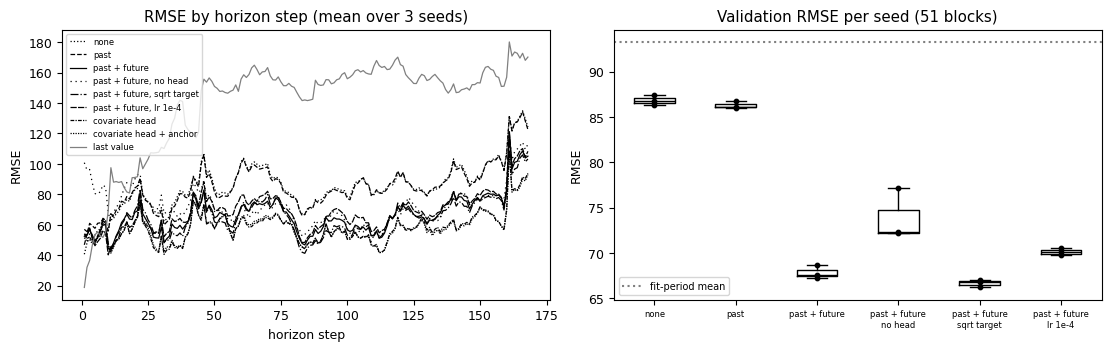

,step 1,steps 1-24,steps 73-96,steps 145-168
none,40.7,66.6,78.6,107.6
past,46.9,69.2,77.8,106.9
past + future,52.5,58.7,60.6,86.8
"past + future, no head",100.8,83.0,64.1,89.3
"past + future, sqrt target",54.1,59.8,56.1,84.7
"past + future, lr 1e-4",57.0,55.7,63.3,88.8
covariate head,53.8,55.0,54.7,73.7
covariate head + anchor,51.6,55.0,54.7,72.9
last value,18.9,72.7,150.2,161.2


In [17]:
curves = {name: np.sqrt(np.mean([((forecasts[name, s] - ACTUAL) ** 2).mean(0) for s in SEEDS], 0)) for name in [*CONFIGS, *IMPROVED]}
curves["last value"] = np.sqrt(((baselines["Last value"] - ACTUAL) ** 2).mean(0))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")
for (name, curve), style in zip(curves.items(), [":", "--", "-", (0, (1, 3)), "-.", (0, (5, 1)), (0, (3, 1, 1, 1)), (0, (1, 1)), "-"]):
    axes[0].plot(np.arange(1, H + 1), curve, color="gray" if name == "last value" else "black", ls=style, lw=0.9, label=name)
axes[0].set(title="RMSE by horizon step (mean over 3 seeds)", xlabel="horizon step", ylabel="RMSE")
axes[0].legend(fontsize=6)
values = [runs[runs.config == name].RMSE.to_numpy() for name in CONFIGS]
axes[1].boxplot(values, tick_labels=[name.replace(", ", "\n") for name in CONFIGS], medianprops=dict(color="black"))
axes[1].tick_params(axis="x", labelsize=6)
for i, v in enumerate(values, 1):
    axes[1].scatter(np.full(len(v), i), v, color="black", s=10)
axes[1].axhline(baseline_table.loc["Fit-period mean", "RMSE"], color="gray", ls=":", label="fit-period mean")
axes[1].set(title="Validation RMSE per seed (51 blocks)", ylabel="RMSE")
axes[1].legend(fontsize=7)
fig.savefig(FIGURES / "T2-2.pdf")
plt.show()
horizon_table = pd.DataFrame({k: [v[0], v[:24].mean(), v[72:96].mean(), v[-24:].mean()] for k, v in curves.items()},
                             index=["step 1", "steps 1-24", "steps 73-96", "steps 145-168"]).T
horizon_table.to_csv(RESULTS / "horizon_rmse.csv")
display(horizon_table.round(1))

## 11. Final model, lag check, forecast and declared P and E



selected: covariate head + anchor | single run mean RMSE 59.27 | average of the 3 seed forecasts, RMSE 58.29 | epochs per refit 5
most selected encoder delays (delay: count): {4: 40, 3: 36, 5: 32, 6: 28, 2: 27, 0: 24, 7: 18, 1: 13, 8: 10, 9: 4}


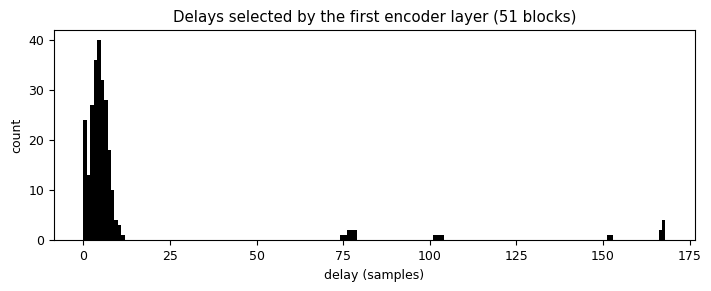

configuration: covariate head + anchor | members: 3
P = 129510 trainable parameters (all members), E = 25 epochs (early stopped run plus refits)


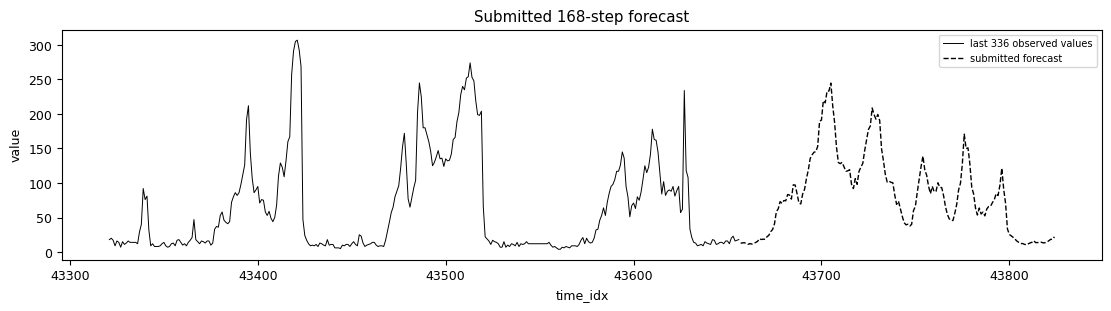

In [18]:
CANDIDATES = {**CONFIGS, **IMPROVED}                   # every arm declared before its results were seen
mean_rmse = runs[runs.config.isin(CANDIDATES)].groupby("config").RMSE.mean()
best = mean_rmse.idxmin()
settings = {**DEFAULT, **CANDIDATES[best]}
rows = runs[runs.config == best]
chosen = rows.loc[rows.stop_loss.idxmin()]
epochs_star = int(round(rows.best_epoch.fillna(rows.epochs).median()))   # epochs of the early stopped runs, reused in the refit
ensemble_validation = metrics(np.mean([forecasts[best, s] for s in SEEDS], 0))
print("selected:", best, "| single run mean RMSE", round(mean_rmse[best], 2), "| average of the 3 seed forecasts, RMSE",
      round(ensemble_validation["RMSE"], 2), "| epochs per refit", epochs_star)

members, full_forecasts = [], []
for seed in SEEDS:                                       # refit on all history with the validated epoch count, no early stopping
    model, scaler, record = train_model(seed, **settings, refit="all", fixed_epochs=epochs_star)
    series = np.concatenate([scaler.scale(y), np.zeros(H)])   # unknown future values are never read
    full_forecasts.append(scaler.unscale(predict(model, np.array([n]), series, settings["covariates"]))[0])
    members.append((model, record))
submission = np.mean(full_forecasts, 0)
P = sum(p.numel() for m, _ in members for p in m.parameters() if p.requires_grad)
E = int(chosen.epochs) + sum(r["epochs"] for _, r in members)    # the early stopped run that fixed the epoch count, plus every refit epoch

model, scaler = members[0][0], Target(settings["target"])
predict(model, block_origins, scaler.scale(y), settings["covariates"])
delays = pd.Series(model.encoder[0].mix.last_delays.flatten().cpu().numpy())
print("most selected encoder delays (delay: count):", delays.value_counts().head(10).to_dict())
fig, axis = plt.subplots(figsize=(7, 2.8), layout="constrained")
axis.hist(delays, bins=np.arange(L + 1), color="black")
axis.set(title="Delays selected by the first encoder layer (51 blocks)", xlabel="delay (samples)", ylabel="count")
fig.savefig(FIGURES / "T2-4.pdf")
plt.show()

assert submission.shape == (H,) and np.isfinite(submission).all() and (submission >= 0).all()
pd.DataFrame({"time_idx": test.time_idx, "value": submission}).to_csv(RESULTS / "submission.csv", index=False)
print("configuration:", best, "| members:", len(members))
print(f"P = {P} trainable parameters (all members), E = {E} epochs (early stopped run plus refits)")
pd.DataFrame([dict(config=best, members=len(members), epochs_per_refit=epochs_star, P=P, E=E,
                   validation_RMSE_single=rows.RMSE.mean(), validation_RMSE_seed_average=ensemble_validation["RMSE"])]).to_csv(
    RESULTS / "final_model.csv", index=False)

fig, axis = plt.subplots(figsize=(11, 3), layout="constrained")
axis.plot(np.arange(n - 336, n) + 1, y[-336:], color="black", lw=0.7, label="last 336 observed values")
axis.plot(test.time_idx, submission, color="black", ls="--", lw=1, label="submitted forecast")
axis.set(xlabel="time_idx", ylabel="value", title="Submitted 168-step forecast")
axis.legend(fontsize=7)
fig.savefig(FIGURES / "T2-3.pdf")
plt.show()


In [19]:
# Leaderboard cost weights. Score minus RMSE equals alpha * P + beta * E. The 22 rows below were read from the
# leaderboard page on 5 Oct 2026 as (RMSE, score, parameters, epochs). The least squares fit recovers the weights.
board = np.array([(62.9497, 62.9599, 53670, 20), (65.0912, 65.1215, 129620, 60), (67.2162, 67.2253, 70086, 18),
                  (69.1586, 69.1612, 7938, 5), (69.1186, 69.1864, 163779, 135), (69.8003, 69.8130, 365187, 24),
                  (71.1714, 71.2795, 51810, 216), (71.3449, 71.3651, 89330, 40), (71.7090, 71.8854, 692565, 350),
                  (83.9416, 83.9479, 635394, 10), (84.2618, 84.2698, 34377, 16), (84.5748, 84.5764, 42561, 3),
                  (84.8070, 84.8123, 152965, 10), (85.0438, 85.0815, 85770, 75), (85.0712, 85.0878, 19683, 33),
                  (85.7514, 85.7769, 225980, 50), (86.3898, 86.3939, 36793, 8), (86.4685, 86.5255, 515142, 112),
                  (88.3236, 88.3297, 69265, 12), (90.8453, 90.8498, 22401, 9), (90.9123, 90.9225, 110560, 20),
                  (92.0024, 92.0125, 42784, 20)])
alpha, beta = np.linalg.lstsq(board[:, 2:], board[:, 1] - board[:, 0], rcond=None)[0]
print(f"alpha = {alpha:.2e} per parameter, beta = {beta:.2e} per epoch, largest fit error {np.abs(board[:, 2:] @ [alpha, beta] - (board[:, 1] - board[:, 0])).max():.5f}")
print(f"cost of this submission: {alpha * P + beta * E:.4f} on top of its RMSE. One million parameters would add {alpha * 1e6:.4f} and one hundred epochs {beta * 100:.4f}.")
print(f"total epochs trained across every run in this notebook: {int(runs.epochs.sum())} (E declared counts only the submitted forecast)")


alpha = 2.00e-09 per parameter, beta = 5.00e-04 per epoch, largest fit error 0.00009
cost of this submission: 0.0128 on top of its RMSE. One million parameters would add 0.0020 and one hundred epochs 0.0500.
total epochs trained across every run in this notebook: 505 (E declared counts only the submitted forecast)


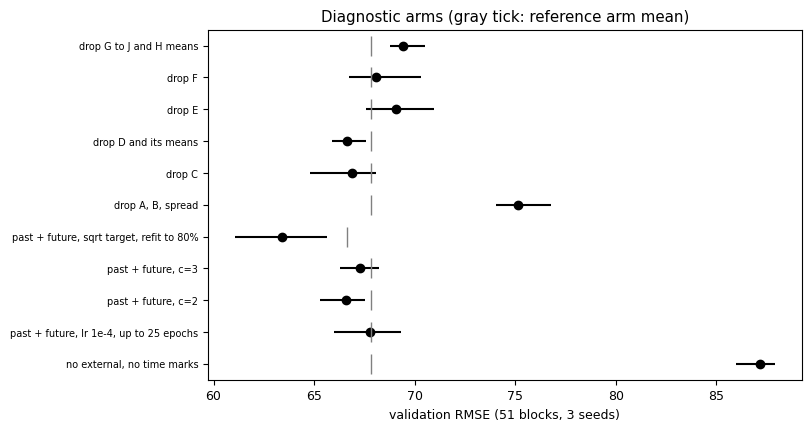

In [20]:
# Figure T2-5: diagnostic arms against their reference arm (mean RMSE over 3 seeds, bars show the seed range).
reference = {"no external, no time marks": "past + future",
             "past + future, lr 1e-4, up to 25 epochs": "past + future",
             "past + future, c=2": "past + future", "past + future, c=3": "past + future",
             "past + future, sqrt target, refit to 80%": "past + future, sqrt target",
             **{f"drop {name}": "past + future" for name in GROUPS}}
rows = []
for name, ref in reference.items():
    v = runs[runs.config == name].RMSE
    rows.append((name, v.mean(), v.min(), v.max(), runs[runs.config == ref].RMSE.mean()))
fig, axis = plt.subplots(figsize=(8, 4.2), layout="constrained")
for i, (name, mean, low, high, ref) in enumerate(rows):
    axis.hlines(i, low, high, color="black", lw=1.5)
    axis.plot(mean, i, "ko")
    axis.plot(ref, i, marker="|", color="gray", ms=14, ls="")
axis.set_yticks(range(len(rows)), [r[0] for r in rows], fontsize=7)
axis.set(xlabel="validation RMSE (51 blocks, 3 seeds)", title="Diagnostic arms (gray tick: reference arm mean)")
fig.savefig(FIGURES / "T2-5.pdf")
plt.show()


In [21]:
# Paste this line into the leaderboard predictions field.
print(", ".join(f"{v:.4f}" for v in submission))

12.5931, 13.2989, 13.4959, 12.2951, 11.1788, 12.2563, 11.4894, 12.6093, 13.8792, 15.4289, 19.2778, 18.1279, 18.6511, 18.3952, 22.0635, 24.2523, 29.5840, 32.5803, 40.8201, 58.3803, 62.6587, 73.0856, 70.4704, 74.5932, 74.2500, 83.2633, 82.5672, 76.7028, 97.2870, 97.0875, 84.7935, 71.0760, 69.7042, 84.0560, 90.8214, 106.3413, 118.7047, 135.3782, 140.7257, 144.5835, 145.3030, 153.1498, 189.4819, 191.1558, 219.1952, 216.1407, 233.2455, 233.2506, 244.7710, 211.8738, 187.6179, 152.0932, 129.6707, 128.0344, 129.9181, 123.3112, 117.0965, 117.5695, 119.2891, 98.0642, 91.9335, 106.4338, 98.0664, 116.8950, 123.0792, 128.4105, 146.8296, 162.4287, 177.4661, 182.5902, 208.6622, 199.1749, 192.4760, 199.3883, 190.4837, 149.3431, 132.0937, 112.5076, 101.2493, 102.5571, 101.0302, 100.2743, 82.6668, 69.1182, 73.6309, 62.7543, 51.9343, 42.6338, 39.4201, 40.2870, 37.5927, 40.1204, 60.1039, 66.3026, 86.4898, 104.8217, 123.5166, 138.9647, 119.2111, 111.2435, 95.4127, 84.6140, 95.1379, 87.2336, 88.0697, 100.35

In [22]:
# Zip results and figures; on Colab the zip downloads automatically.
with zipfile.ZipFile("task2_results.zip", "w") as archive:
    for path in [*RESULTS.rglob("*"), *FIGURES.rglob("*")]:
        archive.write(path)
try:
    from google.colab import files
    files.download("task2_results.zip")
except ImportError:
    print("Saved", Path("task2_results.zip").resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>